<a href="https://colab.research.google.com/github/hafsaDev-ctrl/student-performance-analysis/blob/main/HafsaMazhar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Upload Excel file
from google.colab import files
uploaded = files.upload()

# Load dataset
import pandas as pd
df = pd.read_excel("student_performance_dataset.xlsx")

# First look
print(df.shape)
print(df.info())
print(df.head())

Saving student_performance_dataset.xlsx to student_performance_dataset.xlsx
(205, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
m

In [16]:
# Fix Gender casing
df['Gender'] = df['Gender'].str.title()

# Fix Name casing
df['Name'] = df['Name'].str.title()

# Fix Department inconsistencies
df['Department'] = df['Department'].str.upper().str.strip()

# Fix Age wrong dtype
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].fillna(df['Age'].median(), inplace=True)

# Attendance impossible values
df.loc[(df['Attendance_%'] < 0) | (df['Attendance_%'] > 100), 'Attendance_%'] = None

# Final Score impossible values
df.loc[df['Final_Score'] > 100, 'Final_Score'] = None

# Fill missing values with median
for col in ['Attendance_%','Assignments','Midterm','Study_Hours_Daily','Final_Score']:
    df[col].fillna(df[col].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Final check
print(df.isnull().sum())

Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64


/tmp/ipykernel_17874/317741448.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_17874/317741448.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Index(['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Department',
       'Education_Level', 'Attendance_%', 'Study_Hours_Daily', 'Assignments',
       'Quizzes', 'Midterm', 'Internet_Access', 'Final_Score'],
      dtype='object')


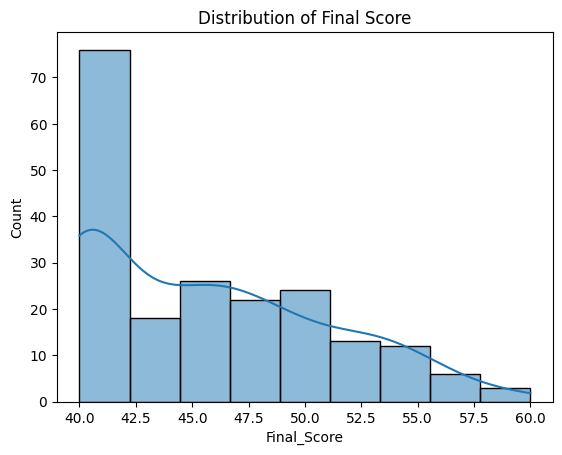

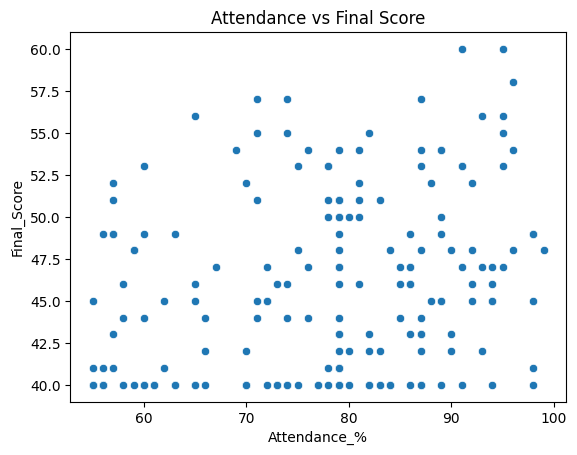

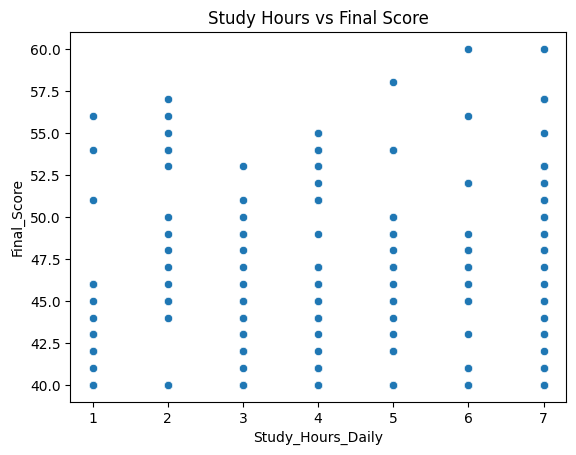

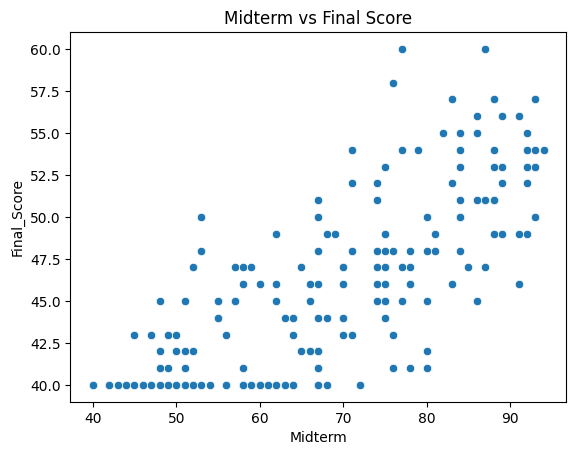

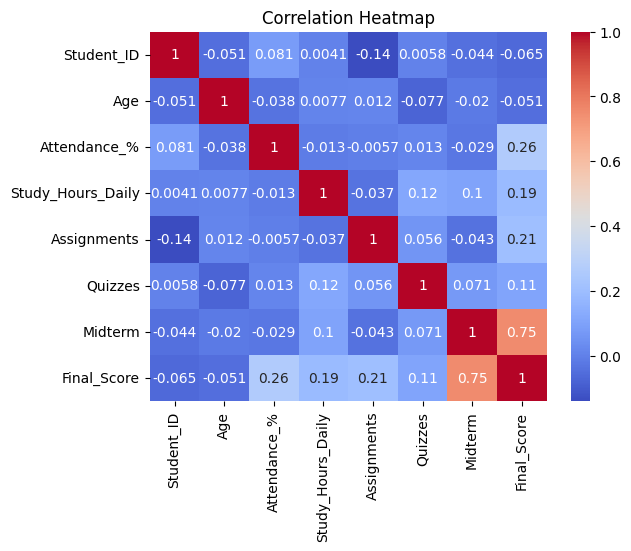

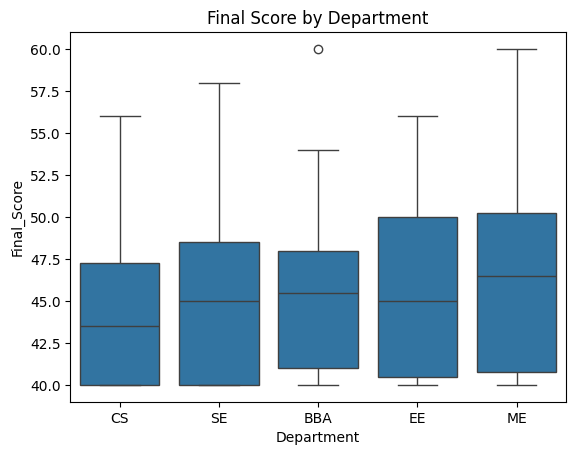

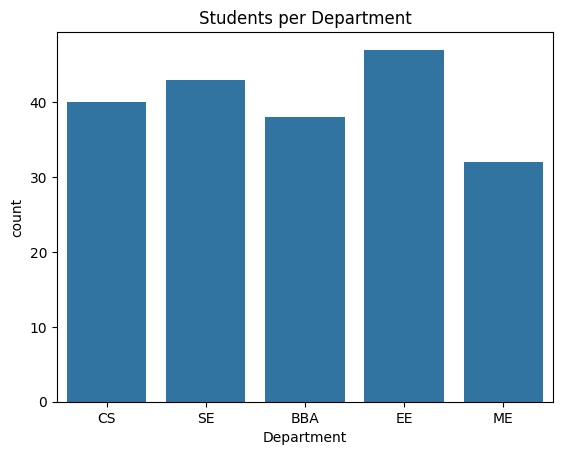

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check column names first
print(df.columns)

# Histogram of Final Score
sns.histplot(df['Final_Score'].dropna(), kde=True)
plt.title("Distribution of Final Score")
plt.show()

# Scatter plots
sns.scatterplot(x='Attendance_%', y='Final_Score', data=df)
plt.title("Attendance vs Final Score")
plt.show()

sns.scatterplot(x='Study_Hours_Daily', y='Final_Score', data=df)
plt.title("Study Hours vs Final Score")
plt.show()

sns.scatterplot(x='Midterm', y='Final_Score', data=df)
plt.title("Midterm vs Final Score")
plt.show()

# Heatmap of numeric correlations
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplot by Department
sns.boxplot(x='Department', y='Final_Score', data=df)
plt.title("Final Score by Department")
plt.show()

# Countplot of Department
sns.countplot(x='Department', data=df)
plt.title("Students per Department")
plt.show()

In [20]:
# New features
df['Total_Academic'] = df['Midterm'] + df['Assignments']*5 + df['Quizzes']*2
df['Attendance_Category'] = pd.cut(df['Attendance_%'], bins=[0,60,80,100], labels=['Low','Medium','High'])

# Train-test split
from sklearn.model_selection import train_test_split
X = df.drop(['Final_Score','Student_ID','Name'], axis=1)
y = df['Final_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

categorical_onehot = ['Gender','Internet_Access','City','Department']
categorical_ordinal = ['Education_Level','Attendance_Category']
numerical = ['Age','Attendance_%','Study_Hours_Daily','Assignments','Quizzes','Midterm','Total_Academic']

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_onehot),
    ('ordinal', OrdinalEncoder(categories=[['Intermediate','Bachelors','Masters'],['Low','Medium','High']]), categorical_ordinal),
    ('scale', StandardScaler(), numerical)
])

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

MAE: 2.4484016880319315
RMSE: 3.265196222552288
R2: 0.5866030875622438
Actual: 52.0, Predicted: 53.30054491444858
Actual: 47.0, Predicted: 52.53912578274985
Actual: 40.0, Predicted: 46.170511093646276
Actual: 48.0, Predicted: 45.326309240305996
Actual: 42.0, Predicted: 41.54313957979922
Actual: 43.0, Predicted: 42.653884923683094
Actual: 50.0, Predicted: 48.024152519064344
Actual: 53.0, Predicted: 50.70211033694207
Actual: 45.0, Predicted: 46.70925489469408
Actual: 41.0, Predicted: 49.637961024326565


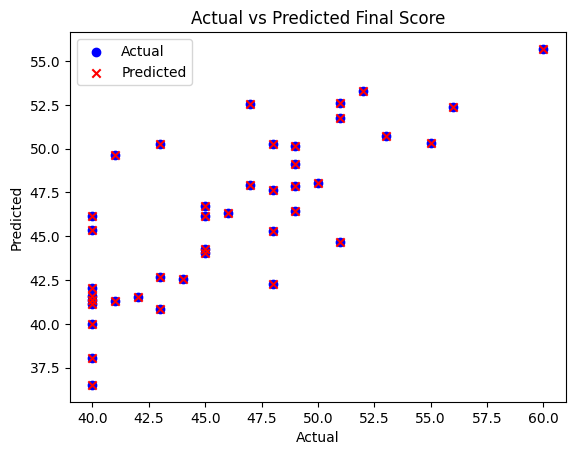

Intercept: 46.75735674267974
Coefficients: [ 0.38735455 -0.38735455  0.09164157 -0.09164157 -0.31991681  0.24412371
  0.05267083  0.91246985 -0.88934758 -0.15305261 -1.05869613  0.05976817
  0.79920854  0.35277203 -0.15604629 -0.84173699  0.07538449  1.88323922
  0.35803183  0.52184701 -0.76469242  2.6356668   1.85609623]


In [21]:
# Train
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

# Actual vs Predicted
for i in range(10):
    print(f"Actual: {y_test.iloc[i]}, Predicted: {y_pred[i]}")

# Scatter plot
plt.scatter(y_test, y_pred, color='blue', label='Actual')
plt.scatter(y_test, y_pred, color='red', marker='x', label='Predicted')
plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Final Score")
plt.show()

# Coefficients
model = pipeline.named_steps['model']
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)